In [1]:
#Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor

In [2]:
#Carga de DataSet
url = "https://ourworldindata.org/grapher/births-and-deaths-projected-to-2100.csv?v=1&csvType=full&useColumnShortNames=true"

try:
    df = pd.read_csv(
        url,
        storage_options={
            "User-Agent": "Our World In Data data fetch/1.0"
        }
    )
except Exception as error:
    print("No fue posible descargar el archivo desde internet:", error)
    print("Se utilizará el archivo local 'births-and-deaths-projected-to-2100.csv'")
    df = pd.read_csv("births-and-deaths-projected-to-2100.csv")

df.head()

,entity,code,year,deaths__sex_all__age_all__variant_estimates,deaths__sex_all__age_all__variant_medium__projected,births__sex_all__age_all__variant_estimates,births__sex_all__age_all__variant_medium__projected
0,Afghanistan,AFG,1950,290972.0,NaN,383985.0,NaN
1,Afghanistan,AFG,1951,288752.0,NaN,391002.0,NaN
2,Afghanistan,AFG,1952,288059.0,NaN,397663.0,NaN
3,Afghanistan,AFG,1953,287712.0,NaN,404666.0,NaN
4,Afghanistan,AFG,1954,289189.0,NaN,410428.0,NaN


In [3]:
#Preparar los nombres de las columnas
df = df.rename(columns={
    "entity": "Entity",
    "code": "Code",
    "year": "Year",
    "births__sex_all__age_all__variant_estimates": "births_estimates",
    "births__sex_all__age_all__variant_medium__projected": "births_projected",
    "deaths__sex_all__age_all__variant_estimates": "deaths_estimates",
    "deaths__sex_all__age_all__variant_medium__projected": "deaths_projected",
})


df.head()

,Entity,Code,Year,deaths_estimates,deaths_projected,births_estimates,births_projected
0,Afghanistan,AFG,1950,290972.0,NaN,383985.0,NaN
1,Afghanistan,AFG,1951,288752.0,NaN,391002.0,NaN
2,Afghanistan,AFG,1952,288059.0,NaN,397663.0,NaN
3,Afghanistan,AFG,1953,287712.0,NaN,404666.0,NaN
4,Afghanistan,AFG,1954,289189.0,NaN,410428.0,NaN


In [4]:
pais = "China"

df_china = df[df["Entity"] == pais]

df_china.head()

,Entity,Code,Year,deaths_estimates,deaths_projected,births_estimates,births_projected
7097,China,CHN,1950,12564023.0,NaN,22293376.0,NaN
7098,China,CHN,1951,12411701.0,NaN,22144814.0,NaN
7099,China,CHN,1952,12459848.0,NaN,25496318.0,NaN
7100,China,CHN,1953,12309525.0,NaN,24139416.0,NaN
7101,China,CHN,1954,12145578.0,NaN,25438544.0,NaN


In [5]:
df["births"] = df["births_estimates"].fillna(df["births_projected"])
df["deaths"] = df["deaths_estimates"].fillna(df["deaths_projected"])
df.head()

,Entity,Code,Year,deaths_estimates,deaths_projected,births_estimates,births_projected,births,deaths
0,Afghanistan,AFG,1950,290972.0,NaN,383985.0,NaN,383985.0,290972.0
1,Afghanistan,AFG,1951,288752.0,NaN,391002.0,NaN,391002.0,288752.0
2,Afghanistan,AFG,1952,288059.0,NaN,397663.0,NaN,397663.0,288059.0
3,Afghanistan,AFG,1953,287712.0,NaN,404666.0,NaN,404666.0,287712.0
4,Afghanistan,AFG,1954,289189.0,NaN,410428.0,NaN,410428.0,289189.0


In [6]:
df_china["births"] = df_china["births_estimates"].fillna(df_china["births_projected"])
df_china["deaths"] = df_china["deaths_estimates"].fillna(df_china["deaths_projected"])

In [7]:
#Identificacion del punto de separacion 
ultimo_historico = df_china.loc[df_china["births_estimates"].notna(), "Year"].max()
primera_proyeccion = df_china.loc[df_china["births_projected"].notna(), "Year"].min()

print("Último año con dato histórico:", ultimo_historico)
print("Primer año con proyección de OWID:", primera_proyeccion)

Último año con dato histórico: 2023
Primer año con proyección de OWID: 2024


# Nacimientos 1980

In [8]:
#Separacion de los años historicos y proyectado

df_historico = df_china[
    df_china["Year"] <= 1980
]

df_proyectado = df_china[
    df_china["Year"] > 1980
]

print(df_historico.head(3))
print(df_proyectado.head(3))

     Entity Code  Year  deaths_estimates  deaths_projected  births_estimates  \
7097  China  CHN  1950        12564023.0               NaN        22293376.0   
7098  China  CHN  1951        12411701.0               NaN        22144814.0   
7099  China  CHN  1952        12459848.0               NaN        25496318.0   

      births_projected      births      deaths  
7097               NaN  22293376.0  12564023.0  
7098               NaN  22144814.0  12411701.0  
7099               NaN  25496318.0  12459848.0  
     Entity Code  Year  deaths_estimates  deaths_projected  births_estimates  \
7128  China  CHN  1981         7493644.0               NaN        22489544.0   
7129  China  CHN  1982         7550026.0               NaN        24352552.0   
7130  China  CHN  1983         7451333.0               NaN        21682298.0   

      births_projected      births     deaths  
7128               NaN  22489544.0  7493644.0  
7129               NaN  24352552.0  7550026.0  
7130              

In [9]:
#Definicion de X e y

X = df_historico[["Year"]]
y_nacimientos = df_historico["births"]

In [10]:
#Convertir los datos a NumPY

X_numpy = X.to_numpy()
y_numpy = y_nacimientos.to_numpy()

print("X_numpy.shape:", X_numpy.shape)
print("y_numpy.shape:", y_numpy.shape)

X_numpy.shape: (31, 1)
y_numpy.shape: (31,)


In [11]:
type(X_numpy), type(y_numpy)

(numpy.ndarray, numpy.ndarray)


# Regresion Lineal

In [12]:
modelo_lineal = LinearRegression()

In [13]:
modelo_lineal.fit(X, y_nacimientos)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[7792.86]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Year']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.013e+07
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [14]:
predicciones_lineal = modelo_lineal.predict(X)

predicciones_lineal[:10]

array([25321686.75806452, 25329479.61935484, 25337272.48064516,
       25345065.34193549, 25352858.20322581, 25360651.06451613,
       25368443.92580645, 25376236.78709677, 25384029.6483871 ,
       25391822.50967742])

In [15]:
print("Pendiente (a):", modelo_lineal.coef_[0])
print("Intercepto (b):", modelo_lineal.intercept_)

Pendiente (a): 7792.861290322587
Intercepto (b): 10125607.241935471


In [16]:
#Años futuros
anios_futuros = np.arange(1980, 2101).reshape(-1, 1)

print("Forma:", anios_futuros.shape)
anios_futuros[:10]

Forma: (121, 1)


array([[1980],
       [1981],
       [1982],
       [1983],
       [1984],
       [1985],
       [1986],
       [1987],
       [1988],
       [1989]])

In [17]:
X_futuro = pd.DataFrame(anios_futuros, columns=["Year"])

X_futuro.head()

,Year
0,1980
1,1981
2,1982
3,1983
4,1984


In [18]:
predicciones_lineal_futuras = modelo_lineal.predict(X_futuro)
print(predicciones_lineal_futuras[:10])

[25555472.59677419 25563265.45806452 25571058.31935484 25578851.18064516
 25586644.04193548 25594436.90322581 25602229.76451613 25610022.62580645
 25617815.48709677 25625608.3483871 ]


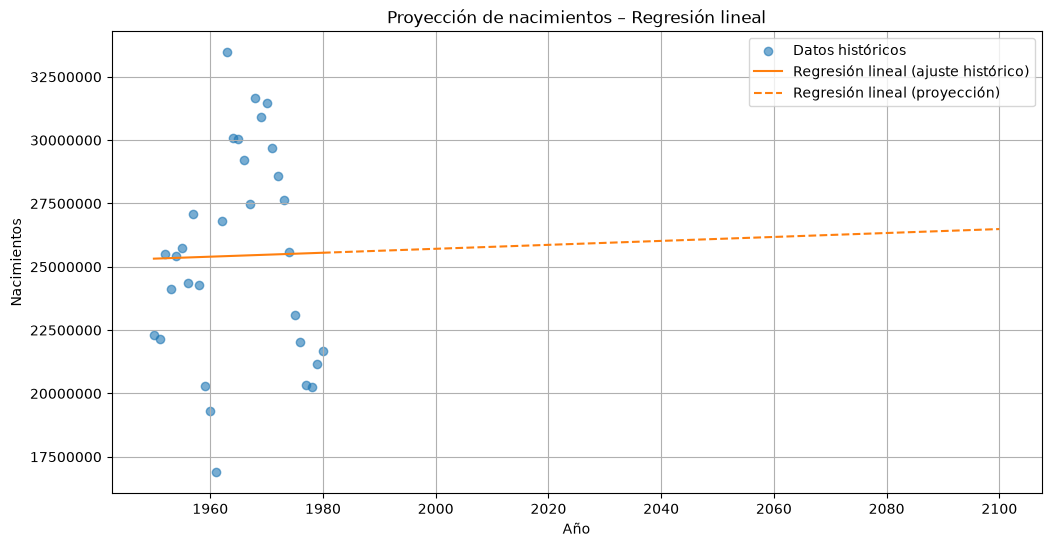

In [19]:
#Comparacion de los datos historicos y predicciones
plt.figure(figsize=(12, 6))

plt.scatter(
    df_historico["Year"],
    df_historico["births"],
    label="Datos históricos",
    alpha=0.6
)

# Ajuste del modelo sobre los años históricos
plt.plot(
    df_historico["Year"],
    predicciones_lineal,
    color="tab:orange",
    label="Regresión lineal (ajuste histórico)"
)

# Proyección hacia el futuro
plt.plot(
    anios_futuros.flatten(),
    predicciones_lineal_futuras,
    color="tab:orange",
    linestyle="--",
    label="Regresión lineal (proyección)"
)

plt.title("Proyección de nacimientos – Regresión lineal")
plt.xlabel("Año")
plt.ylabel("Nacimientos")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

# Regresion polinomial

In [20]:
poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

In [21]:
#Transformacion de X
X_poly = poly.fit_transform(X)

X_poly[:5]

array([[1.950000e+03, 3.802500e+06],
       [1.951000e+03, 3.806401e+06],
       [1.952000e+03, 3.810304e+06],
       [1.953000e+03, 3.814209e+06],
       [1.954000e+03, 3.818116e+06]])

In [22]:
#Entrenar el modelo
modelo_polinomial = LinearRegression()

modelo_polinomial.fit(
    X_poly,
    y_nacimientos
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[0. ,1.85]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.83e+07
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](2,)","[195712.83, 0.1 ]"


In [23]:
predicciones_polinomiales = modelo_polinomial.predict(
    X_poly
)

In [24]:
anios_futuros_poly = poly.transform(
    X_futuro
)

predicciones_polinomiales_futuras = modelo_polinomial.predict(
    anios_futuros_poly
)

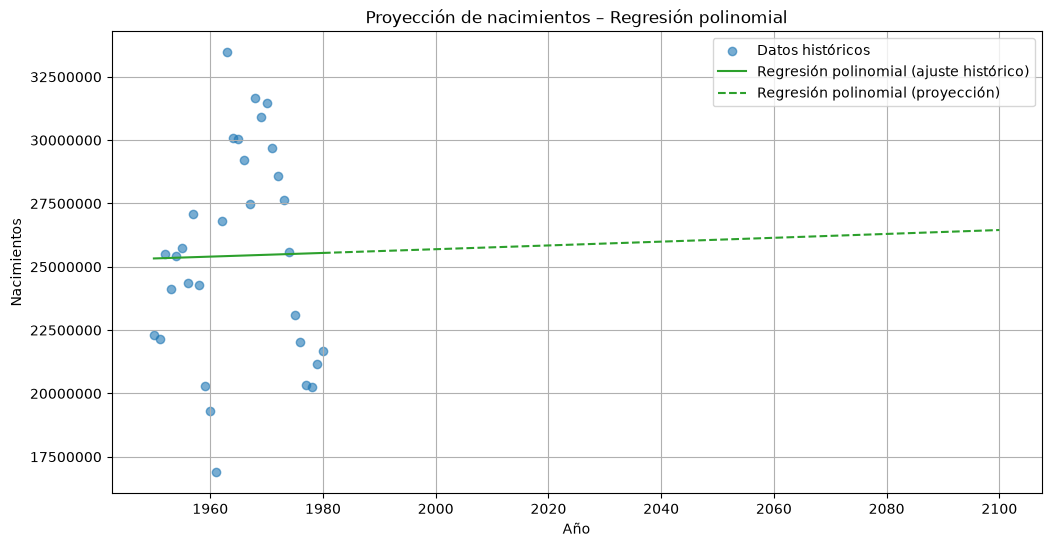

In [25]:
#GRFICA
plt.figure(figsize=(12, 6))

plt.scatter(
    df_historico["Year"],
    df_historico["births"],
    label="Datos históricos",
    alpha=0.6
)

plt.plot(
    df_historico["Year"],
    predicciones_polinomiales,
    color="tab:green",
    label="Regresión polinomial (ajuste histórico)"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_polinomiales_futuras,
    color="tab:green",
    linestyle="--",
    label="Regresión polinomial (proyección)"
)

plt.title("Proyección de nacimientos – Regresión polinomial")
plt.xlabel("Año")
plt.ylabel("Nacimientos")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

# Random Forest 

In [26]:
modelo_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [27]:
modelo_rf.fit(
    X,
    y_nacimientos
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [28]:
#Generamos predicciones historicas
predicciones_rf = modelo_rf.predict(X)
#Generamos proyecciones futuras
predicciones_rf_futuras = modelo_rf.predict(
    X_futuro
)

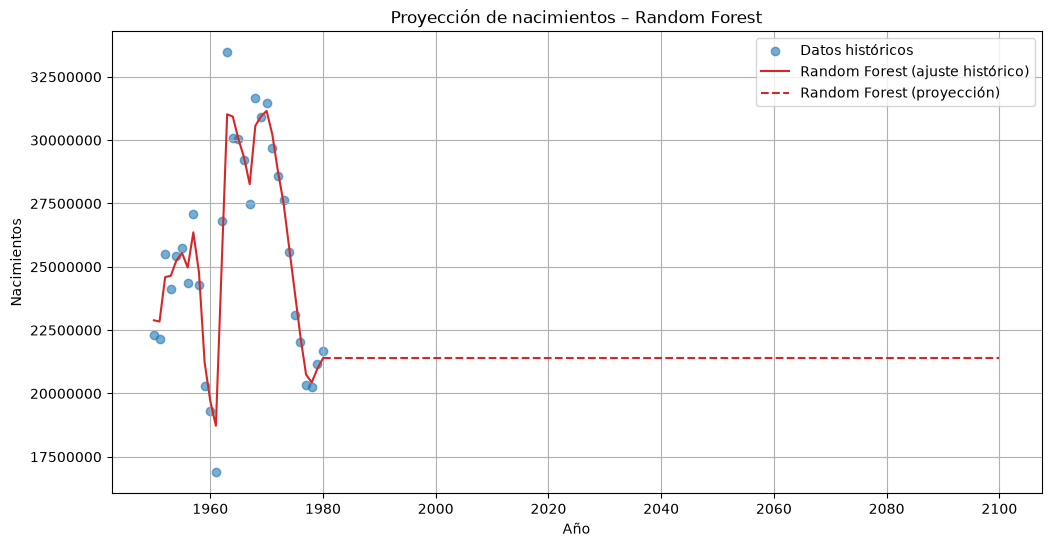

In [29]:
#Graficar
plt.figure(figsize=(12, 6))

plt.scatter(
    df_historico["Year"],
    df_historico["births"],
    label="Datos históricos",
    alpha=0.6
)

plt.plot(
    df_historico["Year"],
    predicciones_rf,
    color="tab:red",
    label="Random Forest (ajuste histórico)"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_rf_futuras,
    color="tab:red",
    linestyle="--",
    label="Random Forest (proyección)"
)

plt.title("Proyección de nacimientos – Random Forest")
plt.xlabel("Año")
plt.ylabel("Nacimientos")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

# Difunciones 

In [30]:
y_defunciones = df_historico["deaths"]

In [31]:
modelo_lineal_deaths = LinearRegression()

modelo_lineal_deaths.fit(
    X,
    y_defunciones
)

predicciones_lineal_deaths = modelo_lineal_deaths.predict(
    X_futuro
)

In [32]:
X = df_historico[["Year"]]
y_defunciones = df_historico["deaths"]

In [33]:
X_numpy = X.to_numpy()
y_numpy = y_defunciones.to_numpy()

print("X_numpy.shape:", X_numpy.shape)
print("y_numpy.shape:", y_numpy.shape)

X_numpy.shape: (31, 1)
y_numpy.shape: (31,)


In [34]:
type(X_numpy), type(y_numpy)

(numpy.ndarray, numpy.ndarray)

## Regresion Lineal 

In [35]:
modelo_lineal = LinearRegression()

In [36]:
#entrenar modelo 
modelo_lineal.fit(X, y_defunciones)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-211997.61]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Year']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.274e+08
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [37]:
print("Pendiente (a):", modelo_lineal.coef_[0])
print("Intercepto (b):", modelo_lineal.intercept_)

Pendiente (a): -211997.6088709677
Intercepto (b): 427413724.7862902


In [38]:
predicciones_lineal = modelo_lineal.predict(X)
predicciones_lineal[:10]

array([14018387.48790324, 13806389.87903225, 13594392.27016127,
       13382394.66129029, 13170397.05241936, 12958399.44354838,
       12746401.8346774 , 12534404.22580642, 12322406.61693549,
       12110409.00806451])

In [39]:
anios_futuros = np.arange(2000, 2101).reshape(-1, 1)

print("Forma:", anios_futuros.shape)
anios_futuros[:10]

Forma: (101, 1)


array([[2000],
       [2001],
       [2002],
       [2003],
       [2004],
       [2005],
       [2006],
       [2007],
       [2008],
       [2009]])

In [40]:
X_futuro = pd.DataFrame(anios_futuros, columns=["Year"])

X_futuro.head()

,Year
0,2000
1,2001
2,2002
3,2003
4,2004


In [41]:
predicciones_lineal_futuras = modelo_lineal.predict(X_futuro)
print(predicciones_lineal_futuras[:10])

[3418507.04435486 3206509.43548387 2994511.82661289 2782514.21774191
 2570516.60887098 2358519.         2146521.39112902 1934523.78225803
 1722526.17338711 1510528.56451613]


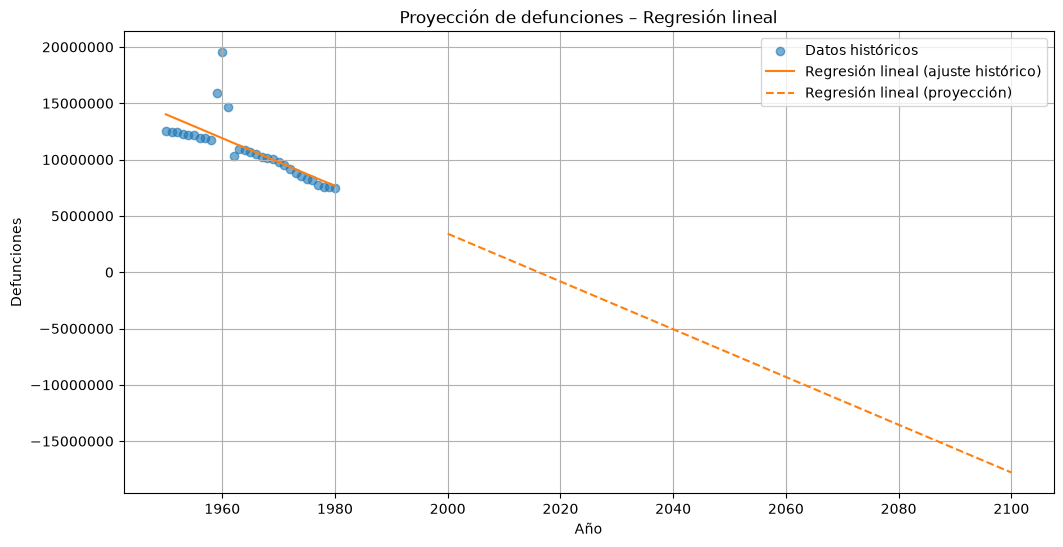

In [42]:
plt.figure(figsize=(12, 6))

plt.scatter(
    df_historico["Year"],
    df_historico["deaths"],
    label="Datos históricos",
    alpha=0.6
)

# Ajuste del modelo sobre los años históricos
plt.plot(
    df_historico["Year"],
    predicciones_lineal,
    color="tab:orange",
    label="Regresión lineal (ajuste histórico)"
)

# Proyección hacia el futuro
plt.plot(
    anios_futuros.flatten(),
    predicciones_lineal_futuras,
    color="tab:orange",
    linestyle="--",
    label="Regresión lineal (proyección)"
)

plt.title("Proyección de defunciones – Regresión lineal")
plt.xlabel("Año")
plt.ylabel("Defunciones")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

## Regresion polinomial para defunciones 

In [43]:
poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

In [44]:
X_poly = poly.fit_transform(X)

X_poly[:5]

array([[1.950000e+03, 3.802500e+06],
       [1.951000e+03, 3.806401e+06],
       [1.952000e+03, 3.810304e+06],
       [1.953000e+03, 3.814209e+06],
       [1.954000e+03, 3.818116e+06]])

In [45]:
#Entrenadar el modelo
modelo_polinomial_deaths = LinearRegression()

modelo_polinomial_deaths.fit(
    X_poly,
    y_defunciones
)

predicciones_polinomiales_deaths = modelo_polinomial_deaths.predict(
    anios_futuros_poly
)

In [46]:
#Generamos predicciones
anios_futuros_poly = poly.transform(
    X_futuro
)

predicciones_polinomiales_futuras = modelo_polinomial.predict(
    anios_futuros_poly
)

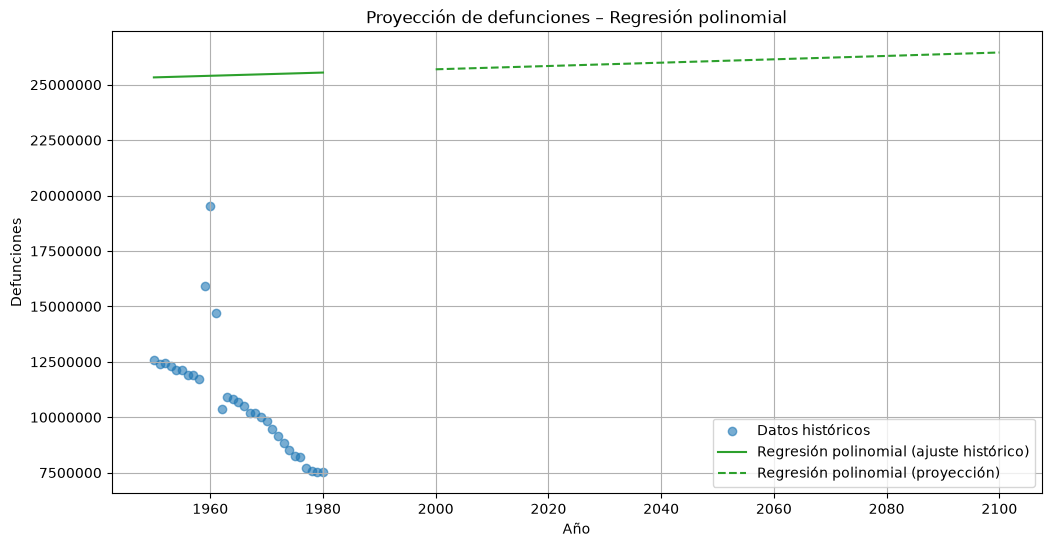

In [47]:
#GRAFICA POLINOMIAL
plt.figure(figsize=(12, 6))

plt.scatter(
    df_historico["Year"],
    df_historico["deaths"],
    label="Datos históricos",
    alpha=0.6
)


plt.plot(
    df_historico["Year"],
    predicciones_polinomiales,
    color="tab:green",
    label="Regresión polinomial (ajuste histórico)"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_polinomiales_futuras,
    color="tab:green",
    linestyle="--",
    label="Regresión polinomial (proyección)"
)

plt.title("Proyección de defunciones – Regresión polinomial")
plt.xlabel("Año")
plt.ylabel("Defunciones")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

## Random Forest 

In [48]:
modelo_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [ ]:
modelo_rf.fit(
    X,
    y_defunciones
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [49]:
#Entrenar el modelo
modelo_rf_deaths = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

modelo_rf_deaths.fit(
    X,
    y_defunciones
)

predicciones_rf_deaths = modelo_rf_deaths.predict(
    X_futuro
)

In [52]:
#GENERAR PREDICCIONES HISTORICAS
predicciones_rf = modelo_rf.predict(X)
#GENERAR PROYECCIONES FUTURAS
predicciones_rf_futuras = modelo_rf.predict(
    X_futuro
)

In [ ]:
plt.figure(figsize=(12, 6))

plt.scatter(
    df_historico["Year"],
    df_historico["deaths"],
    label="Datos históricos",
    alpha=0.6
)

plt.plot(
    df_historico["Year"],
    predicciones_rf,
    color="tab:red",
    label="Random Forest (ajuste histórico)"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_rf_futuras,
    color="tab:red",
    linestyle="--",
    label="Random Forest (proyección)"
)

plt.title("Proyección de defunciones – Random Forest")
plt.xlabel("Año")
plt.ylabel("Defunciones")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

## Regresion polinomial

In [53]:
poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

In [54]:
X_poly = poly.fit_transform(X)

X_poly[:5]

array([[1.950000e+03, 3.802500e+06],
       [1.951000e+03, 3.806401e+06],
       [1.952000e+03, 3.810304e+06],
       [1.953000e+03, 3.814209e+06],
       [1.954000e+03, 3.818116e+06]])

In [55]:
#Entrenadar el modelo
modelo_polinomial_deaths = LinearRegression()

modelo_polinomial_deaths.fit(
    X_poly,
    y_defunciones
)

predicciones_polinomiales_deaths = modelo_polinomial_deaths.predict(
    anios_futuros_poly
)

In [56]:
#Generamos predicciones
anios_futuros_poly = poly.transform(
    X_futuro
)

predicciones_polinomiales_futuras = modelo_polinomial.predict(
    anios_futuros_poly
)

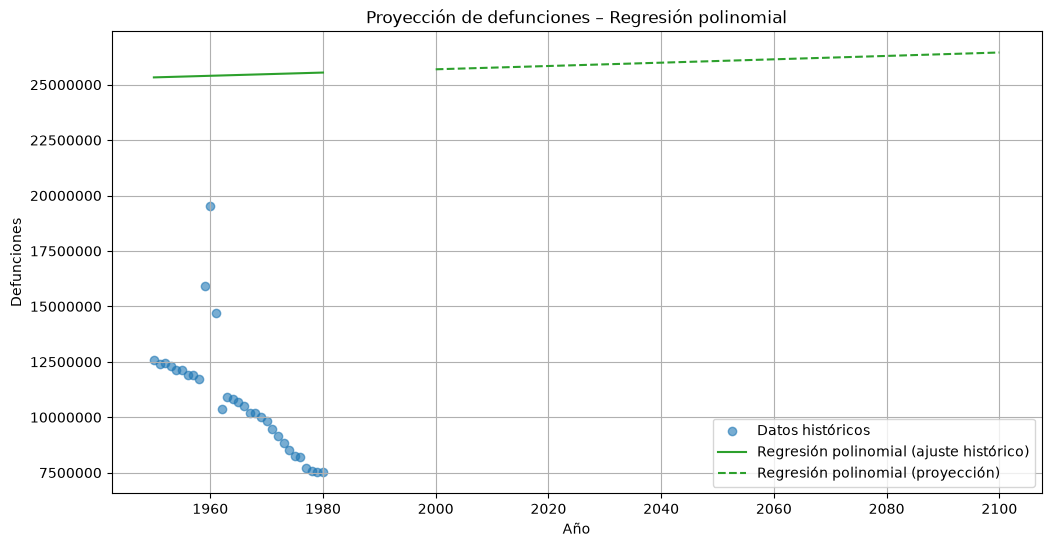

In [57]:
#GRAFICA POLINOMIAL
plt.figure(figsize=(12, 6))

plt.scatter(
    df_historico["Year"],
    df_historico["deaths"],
    label="Datos históricos",
    alpha=0.6
)


plt.plot(
    df_historico["Year"],
    predicciones_polinomiales,
    color="tab:green",
    label="Regresión polinomial (ajuste histórico)"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_polinomiales_futuras,
    color="tab:green",
    linestyle="--",
    label="Regresión polinomial (proyección)"
)

plt.title("Proyección de defunciones – Regresión polinomial")
plt.xlabel("Año")
plt.ylabel("Defunciones")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

## Random Forest

In [59]:
#Entrenar el modelo
modelo_rf_deaths = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

modelo_rf_deaths.fit(
    X,
    y_defunciones
)

predicciones_rf_deaths = modelo_rf_deaths.predict(
    X_futuro
)

In [65]:
#GENERAR PREDICCIONES HISTORICAS
predicciones_rf_deaths = modelo_rf_deaths.predict(X)
#GENERAR PROYECCIONES FUTURAS
predicciones_rf_futuras = modelo_rf_deaths.predict(
    X_futuro
)

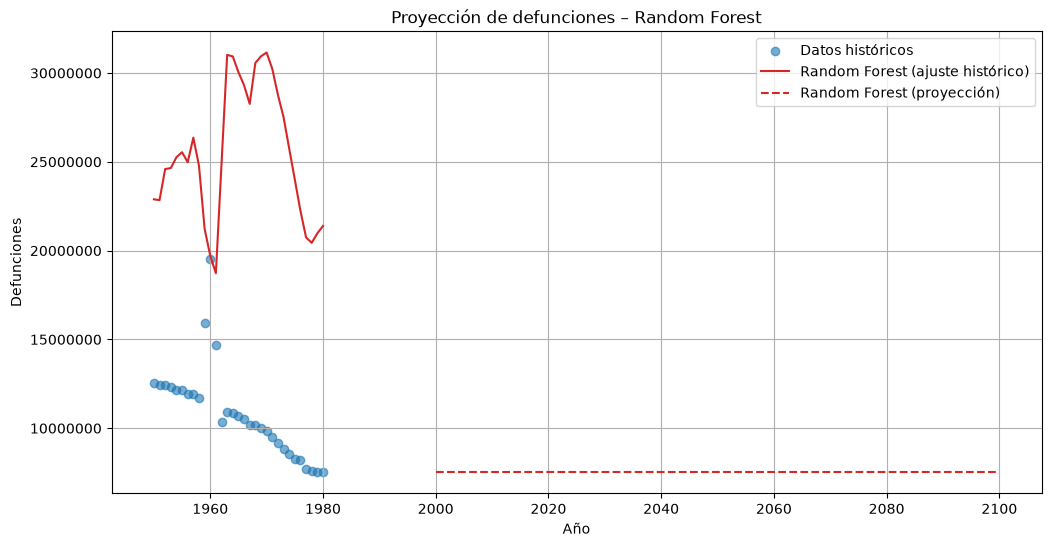

In [66]:
plt.figure(figsize=(12, 6))

plt.scatter(
    df_historico["Year"],
    df_historico["deaths"],
    label="Datos históricos",
    alpha=0.6
)

plt.plot(
    df_historico["Year"],
    predicciones_rf,
    color="tab:red",
    label="Random Forest (ajuste histórico)"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_rf_futuras,
    color="tab:red",
    linestyle="--",
    label="Random Forest (proyección)"
)

plt.title("Proyección de defunciones – Random Forest")
plt.xlabel("Año")
plt.ylabel("Defunciones")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

# Graficar tres modelos

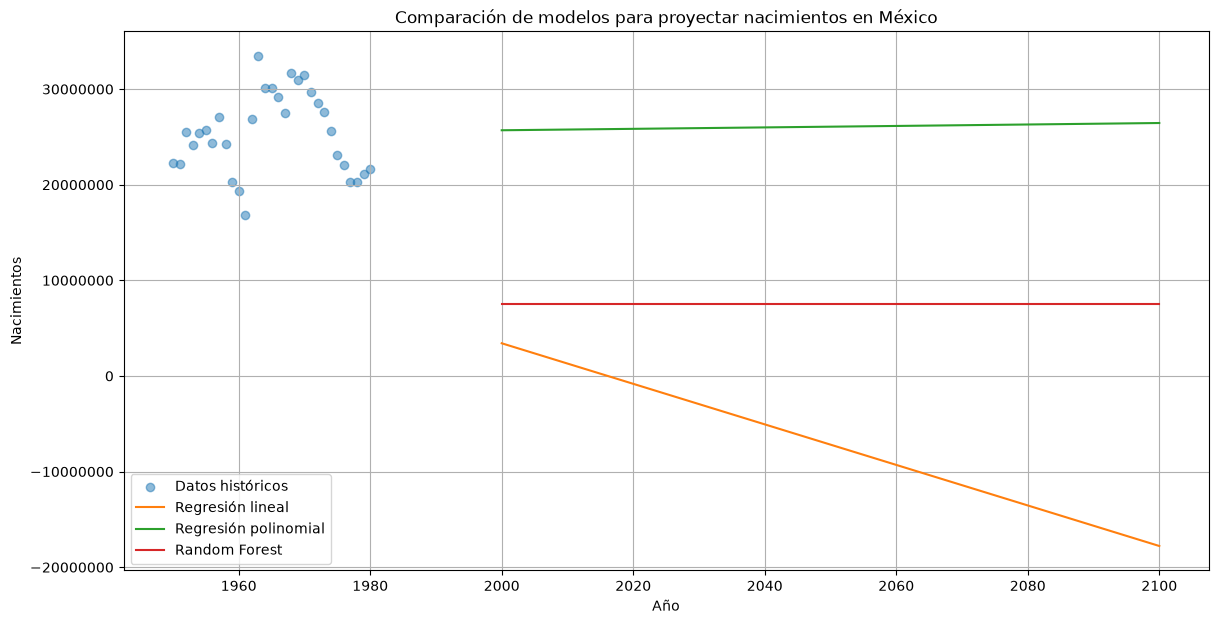

In [67]:
plt.figure(figsize=(14, 7))

plt.scatter(
    df_historico["Year"],
    df_historico["births"],
    label="Datos históricos",
    alpha=0.5
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_lineal_futuras,
    color="tab:orange",
    label="Regresión lineal"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_polinomiales_futuras,
    color="tab:green",
    label="Regresión polinomial"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_rf_futuras,
    color="tab:red",
    label="Random Forest"
)

plt.title(
    "Comparación de modelos para proyectar nacimientos en México"
)

plt.xlabel("Año")
plt.ylabel("Nacimientos")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

# Compararar las predicciones de defunciones